In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import matplotlib.pyplot as plt


# transformation pipeline
transform = transforms.Compose([
    transforms.ToTensor(), # Converts a PIL Image or numpy.ndarray (H x W x C) in the range [0, 255] to a torch.FloatTensor of shape (C x H x W) in the range [0.0, 1.0]
    transforms.Normalize((0.5,), (0.5,)) # Normalize with mean 0.5 and std 0.5 for grayscale images
])

# Fashion MNIST training dataset
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True,
                                                download=True, transform=transform)

# Fashion MNIST test dataset
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False,
                                               download=True, transform=transform)

#  training data loader
batch_size = 64
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                            shuffle=True, num_workers=2)

#  test data loader
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                           shuffle=False, num_workers=2)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Number of batches in training loader: {len(train_loader)}")
print(f"Number of batches in test loader: {len(test_loader)}")

Training dataset size: 60000
Test dataset size: 10000
Number of batches in training loader: 938
Number of batches in test loader: 157


In [ ]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28 * 28, 512),  # Input layer (784) to first hidden layer
            nn.ReLU(),
            nn.Linear(512, 256),   # First hidden layer to second hidden layer
            nn.ReLU(),
            nn.Linear(256, 128),   # Second hidden layer to third hidden layer
            nn.ReLU(),
            nn.Linear(128, 10)     # Third hidden layer to output layer (10 classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork()
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [ ]:
loss_fn = torch.nn.CrossEntropyLoss()

learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print(f"Loss Function: {loss_fn}")
print(f"Optimizer: {optimizer}")

Loss Function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

# training parameters
epochs = 10
train_losses = []
train_accuracies = []

# Training loop
for epoch in range(epochs):
    model.train()  # Set the model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_accuracy = 100 * correct_predictions / total_samples

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

print("Training finished.")

Using device: cpu
Epoch [1/10], Loss: 0.5001, Accuracy: 81.61%
Epoch [2/10], Loss: 0.3755, Accuracy: 86.16%
Epoch [3/10], Loss: 0.3332, Accuracy: 87.74%
Epoch [4/10], Loss: 0.3096, Accuracy: 88.59%
Epoch [5/10], Loss: 0.2870, Accuracy: 89.33%
Epoch [6/10], Loss: 0.2707, Accuracy: 89.84%
Epoch [7/10], Loss: 0.2597, Accuracy: 90.32%
Epoch [8/10], Loss: 0.2423, Accuracy: 90.91%
Epoch [9/10], Loss: 0.2324, Accuracy: 91.30%
Epoch [10/10], Loss: 0.2188, Accuracy: 91.74%
Training finished.


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():  # Disable gradient calculations
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f'Accuracy of the network on the 10000 test images: {test_accuracy:.2f}%')

Accuracy of the network on the 10000 test images: 88.97%


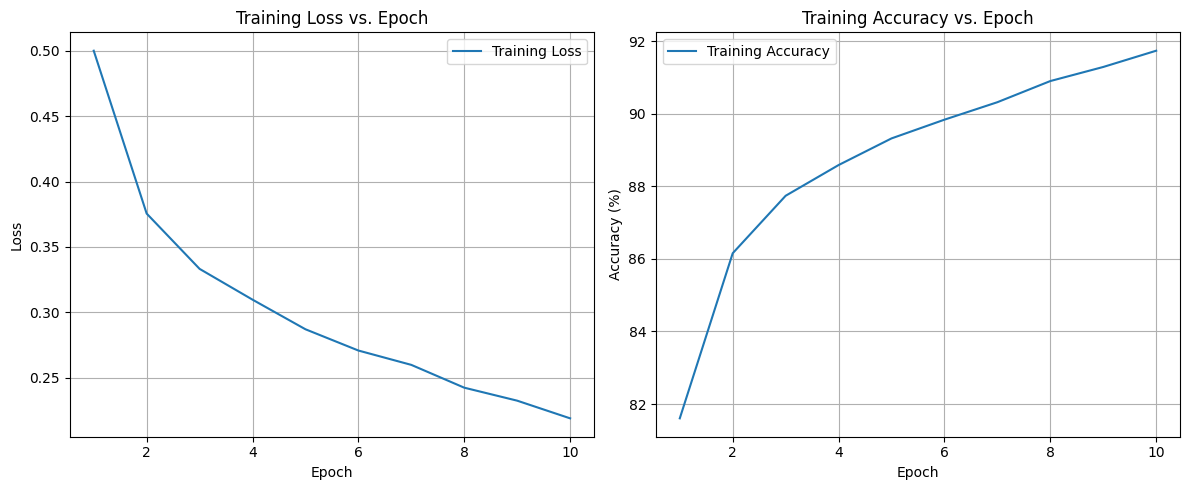

In [ ]:

plt.figure(figsize=(12, 5))

# Training Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.title('Training Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Training Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_accuracies, label='Training Accuracy')
plt.title('Training Accuracy vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout() #
plt.show()

# Interpretation and Conclusion

A multilayer feedforward neural network was defined with one input layer, three hidden layers (512, 256, and 128 neurons respectively) using ReLU activation functions, and a 10-unit output layer.
*   The model was trained for 10 epochs using CrossEntropyLoss as the loss function and Adam optimizer with a learning rate of 0.001.
*   Training loss decreased from 0.5001 in Epoch 1 to 0.2188 in Epoch 10.
*   Training accuracy improved from 81.61% in Epoch 1 to 91.74% in Epoch 10.
*   The final model achieved an accuracy of 88.97% on the test dataset.

